In [2]:
# # Drug Prediction Accuracy
# **GT:** `active_drugs_per_visit.csv` — ground-truth active drug set per visit  
# **Pred:** `pred_active_drugs_per_visit.csv` — 3 predicted options per visit (separated by `|`)  
# **Match rule:** GT drug set == drug set from any of the 3 predicted options

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

HERE = os.path.abspath('')
gt   = pd.read_csv(os.path.join(HERE, 'drug/all_drugs/active_drugs_per_visit.csv'))
pred = pd.read_csv(os.path.join(HERE, 'drug/all_drugs/pred_active_drugs_per_visit.csv'))

assert list(gt.pid) == list(pred.pid), "pid mismatch"
print(f"Patients: {len(gt)}")

def drug_set(cell):
    if pd.isna(cell) or str(cell).strip() == '':
        return frozenset()
    return frozenset(d.strip().lower() for d in str(cell).split(';') if d.strip())

# Build a long-form df: one row per (patient, visit)
rows = []
for i in range(len(gt)):
    pid = gt.iloc[i]['pid']
    for v in ['v1', 'v2', 'v3']:
        gt_drugs = drug_set(gt.iloc[i][v])
        # pred cell has up to 3 options separated by '|'
        pred_cell = str(pred.iloc[i][v]) if pd.notna(pred.iloc[i][v]) else ''
        options = [drug_set(opt) for opt in pred_cell.split('|')] if pred_cell.strip() else []

        if not gt_drugs:
            match = False
            matched_k = None
            mono_poly = 'empty'
        else:
            match = any(gt_drugs == o for o in options)
            matched_k = next((k+1 for k, o in enumerate(options) if gt_drugs == o), None)
            mono_poly = 'mono' if len(gt_drugs) == 1 else 'poly'

        rows.append(dict(
            pid=pid, visit=int(v[1]), mono_poly=mono_poly,
            gt='; '.join(sorted(gt_drugs)), gt_size=len(gt_drugs),
            match=match, matched_k=matched_k,
            opt1='; '.join(sorted(options[0])) if len(options) > 0 else '',
            opt2='; '.join(sorted(options[1])) if len(options) > 1 else '',
            opt3='; '.join(sorted(options[2])) if len(options) > 2 else '',
        ))

df = pd.DataFrame(rows)
print(f"Rows (patient×visit): {len(df)}  |  332×3 = {332*3}")
df.head(6)

Patients: 332
Rows (patient×visit): 996  |  332×3 = 996


,pid,visit,mono_poly,gt,gt_size,match,matched_k,opt1,opt2,opt3
0,1_Nanyonga Aisha,1,mono,valproate,1,True,1.0,valproate,clobazam; valproate,levetiracetam
1,1_Nanyonga Aisha,2,mono,valproate,1,True,1.0,valproate,clobazam; valproate,levetiracetam
2,1_Nanyonga Aisha,3,mono,valproate,1,True,1.0,valproate,lamotrigine,levetiracetam; valproate
3,2_Mwania Sheldon,1,mono,valproate,1,True,3.0,carbamazepine,phenytoin,valproate
4,2_Mwania Sheldon,2,mono,valproate,1,False,NaN,carbamazepine,phenytoin,levetiracetam
5,2_Mwania Sheldon,3,poly,levetiracetam; valproate,2,False,NaN,carbamazepine,levetiracetam,valproate


---
## Overall Accuracy by Visit

 visit   n  correct  accuracy
     1 332      204 61.445783
     2 332      236 71.084337
     3 332      222 66.867470


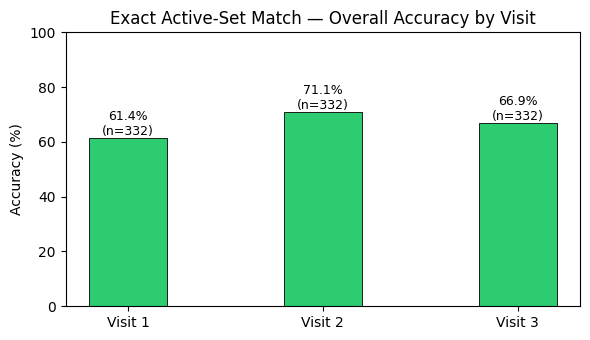

In [4]:
summary = (
    df.groupby('visit')
    .agg(n=('match','count'), correct=('match','sum'))
    .assign(accuracy=lambda x: x['correct']/x['n']*100)
    .reset_index()
)
print(summary.to_string(index=False))

vlabels = summary['visit'].map({1:'Visit 1', 2:'Visit 2', 3:'Visit 3'})
fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.bar(vlabels, summary['accuracy'], color='#2ecc71', edgecolor='black', linewidth=0.6, width=0.4)
for bar, row in zip(bars, summary.itertuples()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{row.accuracy:.1f}%\n(n={row.n})', ha='center', fontsize=9)
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 100)
ax.set_title('Exact Active-Set Match — Overall Accuracy by Visit')
plt.tight_layout(); plt.show()

---
## Mono vs Poly Accuracy by Visit

Mono vs Poly Accuracy by Visit:
  visit  mono  poly  total
Visit 1 75.10 22.97  61.45
Visit 2 89.87 31.07  71.08
Visit 3 93.00 27.27  66.87


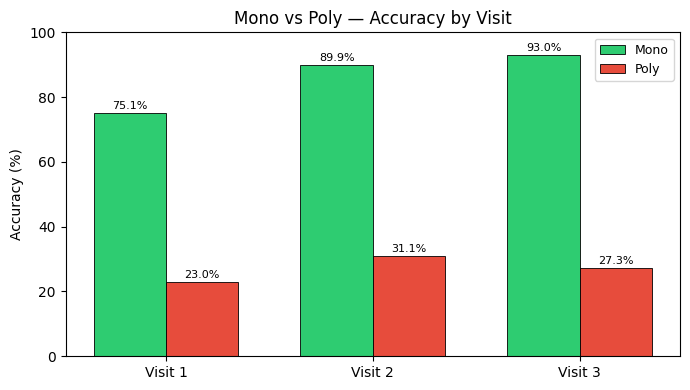

In [5]:
mp = (
    df.groupby(['visit', 'mono_poly'])
    .agg(n=('match','count'), correct=('match','sum'))
    .assign(accuracy=lambda x: x['correct']/x['n']*100)
    .reset_index()
)

# Calculate total accuracy per visit
total_acc = (
    df.groupby('visit')
    .agg(n=('match','count'), correct=('match','sum'))
    .assign(accuracy=lambda x: x['correct']/x['n']*100)
    .reset_index()
)

# Table
mp_pivot = mp.pivot(index='visit', columns='mono_poly', values='accuracy')
mp_pivot = mp_pivot.drop(columns='empty', errors='ignore')
mp_pivot = mp_pivot.reset_index()
mp_pivot['visit'] = mp_pivot['visit'].map({1:'Visit 1', 2:'Visit 2', 3:'Visit 3'})
# Add total accuracy column
mp_pivot['total'] = total_acc['accuracy'].values
print("Mono vs Poly Accuracy by Visit:")
print(mp_pivot.round(2).to_string(index=False))

# Grouped bar chart
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(3)
w = 0.35
mono_acc = mp[mp['mono_poly']=='mono']['accuracy'].values
poly_acc = mp[mp['mono_poly']=='poly']['accuracy'].values

ax.bar(x - w/2, mono_acc, w, label='Mono', color='#2ecc71', edgecolor='black', linewidth=0.6)
ax.bar(x + w/2, poly_acc, w, label='Poly', color='#e74c3c', edgecolor='black', linewidth=0.6)

for i in range(3):
    ax.text(x[i]-w/2, mono_acc[i]+1.2, f'{mono_acc[i]:.1f}%', ha='center', fontsize=8)
    ax.text(x[i]+w/2, poly_acc[i]+1.2, f'{poly_acc[i]:.1f}%', ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(['Visit 1', 'Visit 2', 'Visit 3'])
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 100)
ax.set_title('Mono vs Poly — Accuracy by Visit')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

Poly predictions vs GT poly count:
  visit   n  any_pred_poly  gt_poly
Visit 1 332            127       74
Visit 2 332            220      103
Visit 3 332            223      132


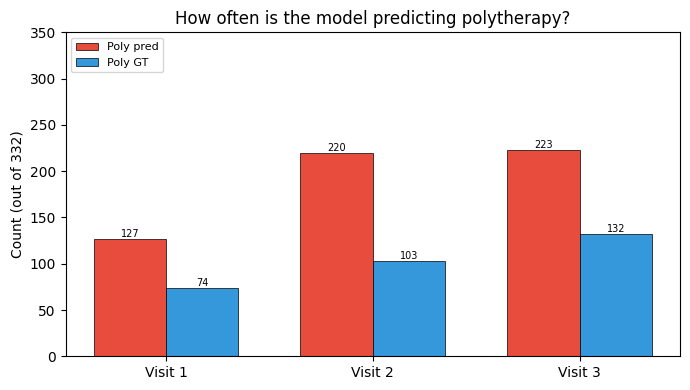

In [6]:
# How often does each predicted option contain polytherapy (2+ drugs)?
def is_poly(cell):
    return len(cell.split('; ')) >= 2 if cell.strip() else False

for col in ['opt1', 'opt2', 'opt3']:
    df[col + '_poly'] = df[col].apply(is_poly)

df['any_pred_poly'] = df[['opt1_poly', 'opt2_poly', 'opt3_poly']].any(axis=1)

poly_pred = (
    df.groupby('visit')
    .agg(
        n=('any_pred_poly', 'count'),
        any_pred_poly=('any_pred_poly', 'sum'),
        gt_poly=('mono_poly', lambda s: (s == 'poly').sum()),
    )
    .reset_index()
)
poly_pred['visit'] = poly_pred['visit'].map({1:'Visit 1', 2:'Visit 2', 3:'Visit 3'})

print("Poly predictions vs GT poly count:")
print(poly_pred.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(3)
w = 0.35
bars_data = [
    ('any_pred_poly', 'Poly pred', '#e74c3c'),
    ('gt_poly', 'Poly GT', '#3498db'),
]
for j, (col, label, color) in enumerate(bars_data):
    vals = poly_pred[col].values
    bars = ax.bar(x + j*w, vals, w, label=label, color=color, edgecolor='black', linewidth=0.5)
    for k, bar in enumerate(bars):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2, str(int(vals[k])),
                ha='center', fontsize=7)
ax.set_xticks(x + 0.5*w)
ax.set_xticklabels(poly_pred['visit'])
ax.set_ylabel('Count (out of 332)')
ax.set_ylim(0, 350)
ax.set_title('How often is the model predicting polytherapy?')
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout(); plt.show()

In [7]:
# Poly patients the model gets wrong
wrong_poly = df[(df['mono_poly'] == 'mono') & (df['match'] == False)]

show_cols = ['pid', 'visit', 'gt', 'gt_size', 'opt1', 'opt2', 'opt3']
with pd.option_context('display.max_colwidth', 60, 'display.max_rows', 500, 'display.width', 220):
    for v in [1, 2, 3]:
        subset = wrong_poly[wrong_poly['visit'] == v][show_cols].reset_index(drop=True)
        total_poly = (df[(df['visit'] == v) & (df['mono_poly'] == 'poly')]).shape[0]
        print(f"\n=== Visit {v} — {len(subset)} wrong / {total_poly} poly patients ===")
        print(subset.to_string(index=False))


=== Visit 1 — 62 wrong / 74 poly patients ===
                    pid  visit            gt  gt_size          opt1          opt2                         opt3
     4_Asio Esther Jane      1  ethosuximide        1     valproate levetiracetam                   topiramate
        5_Nalumu Martha      1 carbamazepine        1     valproate     phenytoin                phenobarbital
         7_Akello Angel      1     valproate        1 carbamazepine phenobarbital                levetiracetam
         8_Tisma Natabi      1 carbamazepine        1     valproate levetiracetam      carbamazepine; clobazam
  9_Nalukwaago Patience      1 carbamazepine        1 levetiracetam     valproate                phenobarbital
     16_Katoosi Timothy      1 carbamazepine        1     valproate levetiracetam      carbamazepine; clobazam
     20_Ainebyona David      1 carbamazepine        1     valproate phenobarbital                levetiracetam
   33_Nakalyango Nicole      1     valproate        1 carbamazepi

In [8]:
# Poly patients the model gets wrong
wrong_poly = df[(df['mono_poly'] == 'poly') & (df['match'] == False)]

show_cols = ['pid', 'visit', 'gt', 'gt_size', 'opt1', 'opt2', 'opt3']
with pd.option_context('display.max_colwidth', 60, 'display.max_rows', 500, 'display.width', 220):
    for v in [1, 2, 3]:
        subset = wrong_poly[wrong_poly['visit'] == v][show_cols].reset_index(drop=True)
        total_poly = (df[(df['visit'] == v) & (df['mono_poly'] == 'poly')]).shape[0]
        print(f"\n=== Visit {v} — {len(subset)} wrong / {total_poly} poly patients ===")
        print(subset.to_string(index=False))


=== Visit 1 — 57 wrong / 74 poly patients ===
                        pid  visit                                                  gt  gt_size          opt1                                   opt2                               opt3
          6_Samiya Mohammed      1                            carbamazepine; valproate        2 carbamazepine                          levetiracetam            carbamazepine; clobazam
          10_Muduku Matthew      1                            levetiracetam; valproate        2 phenobarbital                          carbamazepine                      levetiracetam
            17_Kabito Alpha      1                             ethosuximide; valproate        2     valproate                           ethosuximide                clobazam; valproate
            19_Kimuli Aksam      1                            carbamazepine; valproate        2     valproate                    clobazam; valproate                      levetiracetam
         21_Valencia Wasswa      

How often model predicts poly (any option) — split by GT mono vs poly:

  Visit 1:
    GT mono  → model predicted poly in 81/249 = 32.5%
    GT poly  → model predicted poly in 46/74 = 62.2%
  Visit 2:
    GT mono  → model predicted poly in 126/227 = 55.5%
    GT poly  → model predicted poly in 93/103 = 90.3%
  Visit 3:
    GT mono  → model predicted poly in 108/200 = 54.0%
    GT poly  → model predicted poly in 115/132 = 87.1%


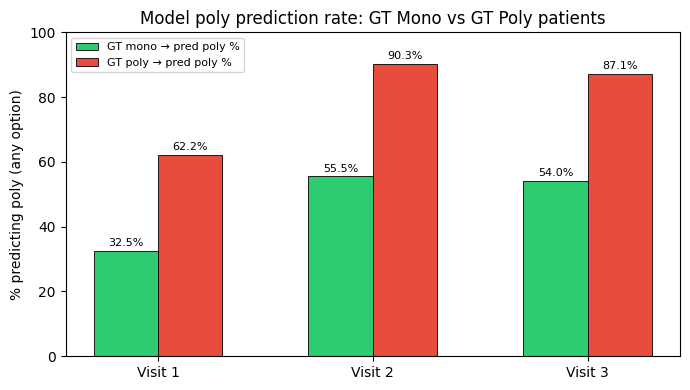

In [9]:
# For GT poly patients: how often did the model predict poly (in any option)?
# For GT mono patients: how often did the model predict poly (in any option)?
cross = (
    df[df['mono_poly'].isin(['mono', 'poly'])]
    .groupby(['visit', 'mono_poly'])
    .agg(
        n=('any_pred_poly', 'count'),
        pred_poly_count=('any_pred_poly', 'sum'),
    )
    .assign(pred_poly_pct=lambda x: (x['pred_poly_count'] / x['n'] * 100).round(1))
    .reset_index()
)

pivot = cross.pivot(index='visit', columns='mono_poly', values=['n', 'pred_poly_count', 'pred_poly_pct'])
# Flatten column names
pivot.columns = [f'{stat}_{mp}' for stat, mp in pivot.columns]
pivot = pivot.reset_index()
pivot['visit'] = pivot['visit'].map({1: 'Visit 1', 2: 'Visit 2', 3: 'Visit 3'})

print("How often model predicts poly (any option) — split by GT mono vs poly:\n")
for _, row in pivot.iterrows():
    print(f"  {row['visit']}:")
    print(f"    GT mono  → model predicted poly in {int(row['pred_poly_count_mono'])}/{int(row['n_mono'])} = {row['pred_poly_pct_mono']}%")
    print(f"    GT poly  → model predicted poly in {int(row['pred_poly_count_poly'])}/{int(row['n_poly'])} = {row['pred_poly_pct_poly']}%")

# Bar chart
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(3)
w = 0.3
mono_vals = cross[cross['mono_poly'] == 'mono']['pred_poly_pct'].values
poly_vals = cross[cross['mono_poly'] == 'poly']['pred_poly_pct'].values

ax.bar(x - w/2, mono_vals, w, label='GT mono → pred poly %', color='#2ecc71', edgecolor='black', linewidth=0.6)
ax.bar(x + w/2, poly_vals, w, label='GT poly → pred poly %', color='#e74c3c', edgecolor='black', linewidth=0.6)

for i in range(3):
    ax.text(x[i]-w/2, mono_vals[i]+1.5, f'{mono_vals[i]:.1f}%', ha='center', fontsize=8)
    ax.text(x[i]+w/2, poly_vals[i]+1.5, f'{poly_vals[i]:.1f}%', ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(['Visit 1', 'Visit 2', 'Visit 3'])
ax.set_ylabel('% predicting poly (any option)')
ax.set_ylim(0, 100)
ax.set_title('Model poly prediction rate: GT Mono vs GT Poly patients')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [10]:
# Print GT and predictions for selected patients
selected_pids = [
    '262_Mutyaba Derrick', '64_Owinyi Golden', '10_Muduku Matthew', '288_Agonzibwa Trevor',
    '95_Lomakol Ives Zane', '90_Odongo Moses', '85_Mirembe Mercy', '67_Ssenyonjo Waswa',
    '320_Nakibirango Calvin', '58_Sekyeru Jeremiah',
    '317_Nantume Shabila', '39_Najjemba Christine', '260_Mukisa Elizabeth',
    '9_Nalukwaago Patience', '8_Tisma Natabi',
    '74_Mukisa Shalom', '131_Muwanguzi Blessed Serugga', '100_Otim Fortunate',
    '227_Muluwaya Arnold', '272_Ogol Jerry'
]

print("### Poly + Wrong (10)")
for i, pid in enumerate(selected_pids[:10], 1):
    rows = df[df['pid'] == pid]
    print(f"{i}. {pid}")
    for _, row in rows.iterrows():
        print(f"   Visit {row['visit']}: GT={row['gt']}, Pred1={row['opt1']}, Pred2={row['opt2']}, Pred3={row['opt3']}")
    print()

print("\n### Mono + Wrong (5)")
for i, pid in enumerate(selected_pids[10:15], 11):
    rows = df[df['pid'] == pid]
    print(f"{i}. {pid}")
    for _, row in rows.iterrows():
        print(f"   Visit {row['visit']}: GT={row['gt']}, Pred1={row['opt1']}, Pred2={row['opt2']}, Pred3={row['opt3']}")
    print()

print("\n### Poly + Correct (3)")
for i, pid in enumerate(selected_pids[15:18], 16):
    rows = df[df['pid'] == pid]
    print(f"{i}. {pid}")
    for _, row in rows.iterrows():
        print(f"   Visit {row['visit']}: GT={row['gt']}, Pred1={row['opt1']}, Pred2={row['opt2']}, Pred3={row['opt3']}")
    print()

print("\n### Mono + Correct (2)")
for i, pid in enumerate(selected_pids[18:20], 19):
    rows = df[df['pid'] == pid]
    print(f"{i}. {pid}")
    for _, row in rows.iterrows():
        print(f"   Visit {row['visit']}: GT={row['gt']}, Pred1={row['opt1']}, Pred2={row['opt2']}, Pred3={row['opt3']}")
    print()

### Poly + Wrong (10)
1. 262_Mutyaba Derrick
   Visit 1: GT=phenobarbital; valproate, Pred1=valproate, Pred2=phenobarbital, Pred3=levetiracetam
   Visit 2: GT=phenobarbital; valproate, Pred1=valproate, Pred2=phenobarbital; valproate, Pred3=levetiracetam; valproate
   Visit 3: GT=phenobarbital; valproate, Pred1=valproate, Pred2=phenobarbital; valproate, Pred3=levetiracetam; valproate

2. 64_Owinyi Golden
   Visit 1: GT=carbamazepine; phenobarbital; topiramate; valproate, Pred1=carbamazepine, Pred2=phenobarbital, Pred3=valproate
   Visit 2: GT=carbamazepine; phenobarbital; topiramate; valproate, Pred1=phenobarbital, Pred2=levetiracetam; phenobarbital, Pred3=lamotrigine; phenobarbital
   Visit 3: GT=carbamazepine; phenobarbital; topiramate; valproate, Pred1=valproate, Pred2=phenobarbital; valproate, Pred3=phenobarbital

3. 10_Muduku Matthew
   Visit 1: GT=levetiracetam; valproate, Pred1=phenobarbital, Pred2=carbamazepine, Pred3=levetiracetam
   Visit 2: GT=levetiracetam; valproate, Pred1=

### Poly + Wrong (10)
1. 262_Mutyaba Derrick
2. 64_Owinyi Golden
3. 10_Muduku Matthew
4. 288_Agonzibwa Trevor
5. 95_Lomakol Ives Zane
6. 90_Odongo Moses
7. 85_Mirembe Mercy
8. 67_Ssenyonjo Waswa
9. 320_Nakibirango Calvin
10. 58_Sekyeru Jeremiah

### Mono + Wrong (5)
11. 317_Nantume Shabila
12. 39_Najjemba Christine
13. 260_Mukisa Elizabeth
14. 9_Nalukwaago Patience
15. 8_Tisma Natabi

### Poly + Correct (3)
16. 74_Mukisa Shalom
17. 131_Muwanguzi Blessed Serugga
18. 100_Otim Fortunate

### Mono + Correct (2)
19. 227_Muluwaya Arnold
20. 272_Ogol Jerry

In [11]:
# --- Mono/Poly/No drug breakdown per visit ---
counts = (
    df.groupby(['visit', 'mono_poly'])
    .size()
    .unstack(fill_value=0)
)
counts['total'] = counts.sum(axis=1)
counts.index = counts.index.map({1: 'Visit 1', 2: 'Visit 2', 3: 'Visit 3'})

# Rename 'empty' column to 'no drug' for display
if 'empty' in counts.columns:
    counts = counts.rename(columns={'empty': 'no drug'})

print("Mono / Poly / No drug counts per visit:")
print(counts)
print()

# --- Transitions between visits ---
# Pivot to wide: one row per patient, columns = visit mono_poly
wide = df[['pid', 'visit', 'mono_poly']].pivot(index='pid', columns='visit', values='mono_poly')
wide.columns = ['v1', 'v2', 'v3']

# Replace 'empty' with 'no drug' for display
wide = wide.replace('empty', 'no drug')

def transition_label(row, a, b):
    return f"{row[a]} → {row[b]}"

for pair, (a, b) in [('V1→V2', ('v1', 'v2')), ('V2→V3', ('v2', 'v3')), ('V1→V3', ('v1', 'v3'))]:
    wide[pair] = wide.apply(lambda r: transition_label(r, a, b), axis=1)

print("=== Transitions V1 → V2 ===")
print(wide['V1→V2'].value_counts().to_string())
print()
print("=== Transitions V2 → V3 ===")
print(wide['V2→V3'].value_counts().to_string())
print()
print("=== Transitions V1 → V3 (overall) ===")
print(wide['V1→V3'].value_counts().to_string())

Mono / Poly / No drug counts per visit:
mono_poly  no drug  mono  poly  total
visit                                
Visit 1          9   249    74    332
Visit 2          2   227   103    332
Visit 3          0   200   132    332

=== Transitions V1 → V2 ===
V1→V2
mono → mono          216
poly → poly           70
mono → poly           33
no drug → mono         8
poly → mono            3
poly → no drug         1
no drug → no drug      1

=== Transitions V2 → V3 ===
V2→V3
mono → mono       197
poly → poly       101
mono → poly        30
poly → mono         2
no drug → poly      1
no drug → mono      1

=== Transitions V1 → V3 (overall) ===
V1→V3
mono → mono       187
poly → poly        70
mono → poly        62
no drug → mono      9
poly → mono         4


Ground-truth active-drug count distribution per visit:
# drugs  0    1    2   3  4  6
visit                         
Visit 1  9  249   61  11  2  0
Visit 2  2  227   83  16  4  0
Visit 3  0  200  100  26  5  1

Bucketed (0 / 1 / 2 / 3+):
# drugs  0    1    2  3+  total
visit                          
Visit 1  9  249   61  13    332
Visit 2  2  227   83  20    332
Visit 3  0  200  100  32    332

Overall (all visits combined):
# drugs
0     11
1    676
2    244
3     53
4     11
6      1

Total rows: 996


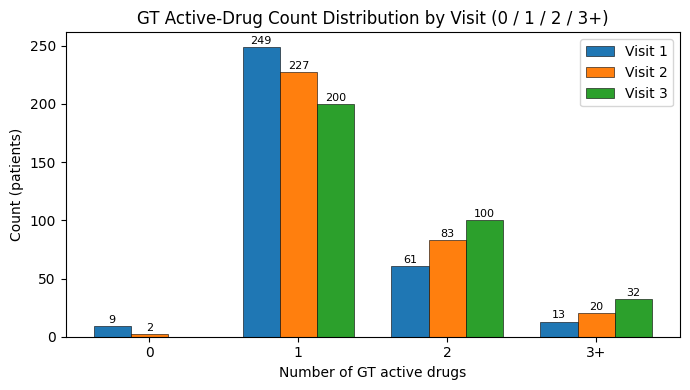

In [12]:
# --- Distribution of GT active-drug count per visit ---
dist = (
    df.groupby(['visit', 'gt_size'])
    .size()
    .unstack(fill_value=0)
)
dist.index = dist.index.map({1: 'Visit 1', 2: 'Visit 2', 3: 'Visit 3'})
dist.columns.name = '# drugs'

print("Ground-truth active-drug count distribution per visit:")
print(dist)
print()

# Bucketed table: 0, 1, 2, 3+
def bucket_label(n):
    return '3+' if n >= 3 else str(n)

df['gt_bucket'] = df['gt_size'].apply(bucket_label)
bucket_order = ['0', '1', '2', '3+']

dist_bucketed = (
    df.groupby(['visit', 'gt_bucket'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=bucket_order, fill_value=0)
)
dist_bucketed['total'] = dist_bucketed.sum(axis=1)
dist_bucketed.index = dist_bucketed.index.map({1: 'Visit 1', 2: 'Visit 2', 3: 'Visit 3'})
dist_bucketed.columns.name = '# drugs'

print("Bucketed (0 / 1 / 2 / 3+):")
print(dist_bucketed)
print()

# Overall (across all visits)
overall = df['gt_size'].value_counts().sort_index()
overall.index.name = '# drugs'
print("Overall (all visits combined):")
print(overall.to_string())
print(f"\nTotal rows: {overall.sum()}")

# Bar chart (bucketed)
fig, ax = plt.subplots(figsize=(7, 4))
visits = ['Visit 1', 'Visit 2', 'Visit 3']
width = 0.25
for i, visit in enumerate(visits):
    counts = [dist_bucketed.loc[visit, b] for b in bucket_order]
    bars = ax.bar([pos + i * width for pos in range(len(bucket_order))], counts, width,
                  label=visit, edgecolor='black', linewidth=0.4)
    for bar, cnt in zip(bars, counts):
        if cnt > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    str(cnt), ha='center', va='bottom', fontsize=8)
ax.set_xticks([pos + width for pos in range(len(bucket_order))])
ax.set_xticklabels(bucket_order)
ax.set_xlabel('Number of GT active drugs')
ax.set_ylabel('Count (patients)')
ax.set_title('GT Active-Drug Count Distribution by Visit (0 / 1 / 2 / 3+)')
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
# --- Patients with 4 or 5 GT active drugs (by visit) ---
for n_drugs in [4, 5]:
    subset = df[df['gt_size'] == n_drugs][['pid', 'visit', 'gt']].sort_values(['visit', 'pid'])
    if subset.empty:
        print(f"No patients with {n_drugs} GT active drugs.\n")
        continue
    print(f"=== Patients with {n_drugs} GT active drugs ({len(subset)} rows) ===")
    for _, row in subset.iterrows():
        print(f"  Visit {row['visit']}  |  {row['pid']}  |  {row['gt']}")
    print()

=== Patients with 4 GT active drugs (11 rows) ===
  Visit 1  |  58_Sekyeru Jeremiah  |  carbamazepine; clobazam; phenobarbital; valproate
  Visit 1  |  64_Owinyi Golden  |  carbamazepine; phenobarbital; topiramate; valproate
  Visit 2  |  215_Nakyeyune Martha  |  carbamazepine; levetiracetam; topiramate; valproate
  Visit 2  |  58_Sekyeru Jeremiah  |  carbamazepine; clobazam; phenobarbital; valproate
  Visit 2  |  64_Owinyi Golden  |  carbamazepine; phenobarbital; topiramate; valproate
  Visit 2  |  77_Promise Ambrose  |  clonazepam; lamotrigine; topiramate; valproate
  Visit 3  |  215_Nakyeyune Martha  |  carbamazepine; levetiracetam; topiramate; valproate
  Visit 3  |  284_Kanyange Fahiah  |  clobazam; lamotrigine; topiramate; valproate
  Visit 3  |  312_Hussein Adila  |  clobazam; lamotrigine; levetiracetam; valproate
  Visit 3  |  64_Owinyi Golden  |  carbamazepine; phenobarbital; topiramate; valproate
  Visit 3  |  77_Promise Ambrose  |  clonazepam; lamotrigine; topiramate; valpro

---
## Accuracy Conditioned on Seizure Frequency Outcome

- **Visit 1 predictions** conditioned on SF at 6 months
- **Visit 2 predictions** conditioned on SF at 12 months

Groups: **Reduced** = Reduced + Seizure-free · **Not Reduced** = everything else (Unchanged, Increased, Other, Unknown)

                             Reduced        Increased
V1 (SF @ 6mo)          63.1% (n=260)   55.6% (n= 72)   Total: 61.4% (n=332)
V2 (SF @ 12mo)         75.6% (n=279)   47.2% (n= 53)   Total: 71.1% (n=332)


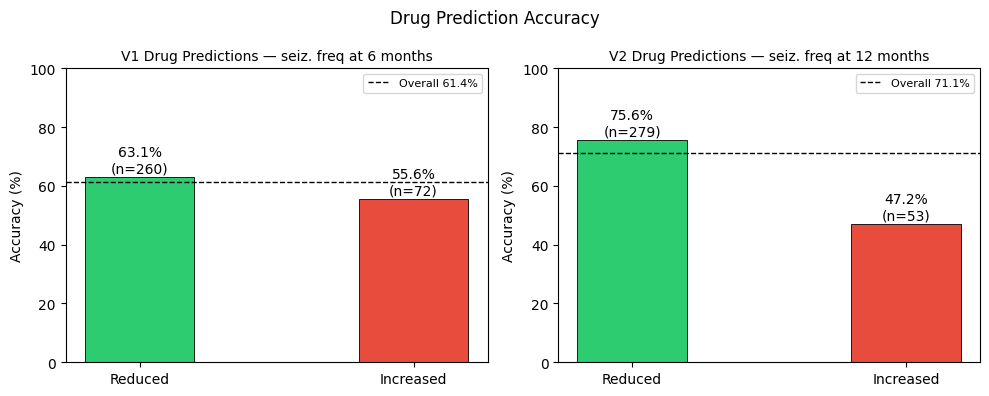

In [18]:

# Load seizure frequency outcome from raw CSV
raw_csv = pd.read_csv('../data/combined_dataset.csv', sep=';', engine='python', quotechar='"', doublequote=True, escapechar='\\')
raw_csv = raw_csv.drop_duplicates(subset=['Record ID'])
raw_csv['record_id'] = pd.to_numeric(raw_csv['Record ID'], errors='coerce').astype('Int64')

df['record_id'] = df['pid'].str.split('_').str[0].apply(pd.to_numeric, errors='coerce').astype('Int64')

raw_sf = raw_csv[['record_id', 'Seizure frequency (6 months)', 'Seizure frequency (12 months)']].rename(columns={
    'Seizure frequency (6 months)': 'sf_6mo',
    'Seizure frequency (12 months)': 'sf_12mo',
})
df2 = df.merge(raw_sf, on='record_id', how='left')

def sf_group(val):
    if pd.isna(val):
        return 'Increased'
    return 'Reduced' if str(val).strip() in ('Reduced', 'Seizure-free') else 'Increased'

df2['sf_6mo_group']  = df2['sf_6mo'].apply(sf_group)
df2['sf_12mo_group'] = df2['sf_12mo'].apply(sf_group)

GROUP_ORDER = ['Reduced', 'Increased']

def acc_by_group(sub, group_col):
    out = (
        sub.groupby(group_col)
        .agg(n=('match', 'count'), correct=('match', 'sum'))
        .assign(accuracy=lambda x: x['correct'] / x['n'] * 100)
        .reset_index()
    )
    out[group_col] = pd.Categorical(out[group_col], categories=GROUP_ORDER, ordered=True)
    return out.sort_values(group_col).reset_index(drop=True)

acc_v1 = acc_by_group(df2[df2['visit'] == 1], 'sf_6mo_group')
acc_v2 = acc_by_group(df2[df2['visit'] == 2], 'sf_12mo_group')

# Overall accuracy for V1 and V2
total_v1 = df2[df2['visit'] == 1]['match'].mean() * 100
total_v2 = df2[df2['visit'] == 2]['match'].mean() * 100
total_n_v1 = len(df2[df2['visit'] == 1])
total_n_v2 = len(df2[df2['visit'] == 2])

# Print table
print("=" * 55)
print(f"{'':20s} {'Reduced':>15s}  {'Increased':>15s}")
print("=" * 55)
for label, acc, total_acc, total_n in [
    ("V1 (SF @ 6mo)", acc_v1, total_v1, total_n_v1),
    ("V2 (SF @ 12mo)", acc_v2, total_v2, total_n_v2),
]:
    r  = acc[acc['sf_6mo_group' if 'sf_6mo_group' in acc.columns else 'sf_12mo_group'] == 'Reduced'].iloc[0]
    nr = acc[acc['sf_6mo_group' if 'sf_6mo_group' in acc.columns else 'sf_12mo_group'] == 'Increased'].iloc[0]
    print(f"{label:20s}  {r['accuracy']:5.1f}% (n={int(r['n']):3d})  {nr['accuracy']:5.1f}% (n={int(nr['n']):3d})   Total: {total_acc:.1f}% (n={total_n})")
print("=" * 55)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
COLORS = {'Reduced': '#2ecc71', 'Increased': '#e74c3c'}

for ax, acc, gcol, title, sub, total_acc in [
    (axes[0], acc_v1, 'sf_6mo_group',  'V1 Drug Predictions', 'seiz. freq at 6 months',  total_v1),
    (axes[1], acc_v2, 'sf_12mo_group', 'V2 Drug Predictions', 'seiz. freq at 12 months', total_v2),
]:
    groups = acc[gcol].tolist()
    vals   = acc['accuracy'].tolist()
    ns     = acc['n'].tolist()
    bars = ax.bar(groups, vals, color=[COLORS[g] for g in groups],
                  edgecolor='black', linewidth=0.6, width=0.4)
    for bar, val, n in zip(bars, vals, ns):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                f'{val:.1f}%\n(n={n})', ha='center', fontsize=10)
    ax.axhline(total_acc, color='black', linestyle='--', linewidth=1, label=f'Overall {total_acc:.1f}%')
    ax.set_ylim(0, 100)
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(f'{title} — {sub}', fontsize=10)
    ax.legend(fontsize=8)

fig.suptitle('Drug Prediction Accuracy', fontsize=12)
plt.tight_layout()
plt.show()
